In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# load csv file
df = pd.read_csv('nitrate.csv',header=0)
print(df.head)

<bound method NDFrame.head of                  Date   NO3N  Student_Flag
0      8/2/2016 12:29  0.071             0
1      8/2/2016 12:59  0.030             0
2      8/2/2016 13:29  0.030             0
3      8/2/2016 13:59  0.030             0
4      8/2/2016 14:29  0.030             0
...               ...    ...           ...
30785   5/7/2018 6:59  0.219             0
30786   5/7/2018 7:29  0.117             0
30787   5/7/2018 7:59  0.099             0
30788   5/7/2018 8:29  0.217             0
30789   5/7/2018 8:59  0.074             0

[30790 rows x 3 columns]>


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.info())
print(df.isna().sum())

                 Date   NO3N  Student_Flag
0 2016-08-02 12:29:00  0.071             0
1 2016-08-02 12:59:00  0.030             0
2 2016-08-02 13:29:00  0.030             0
3 2016-08-02 13:59:00  0.030             0
4 2016-08-02 14:29:00  0.030             0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30790 entries, 0 to 30789
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          30790 non-null  datetime64[ns]
 1   NO3N          30790 non-null  float64       
 2   Student_Flag  30790 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 721.8 KB
None
Date            0
NO3N            0
Student_Flag    0
dtype: int64


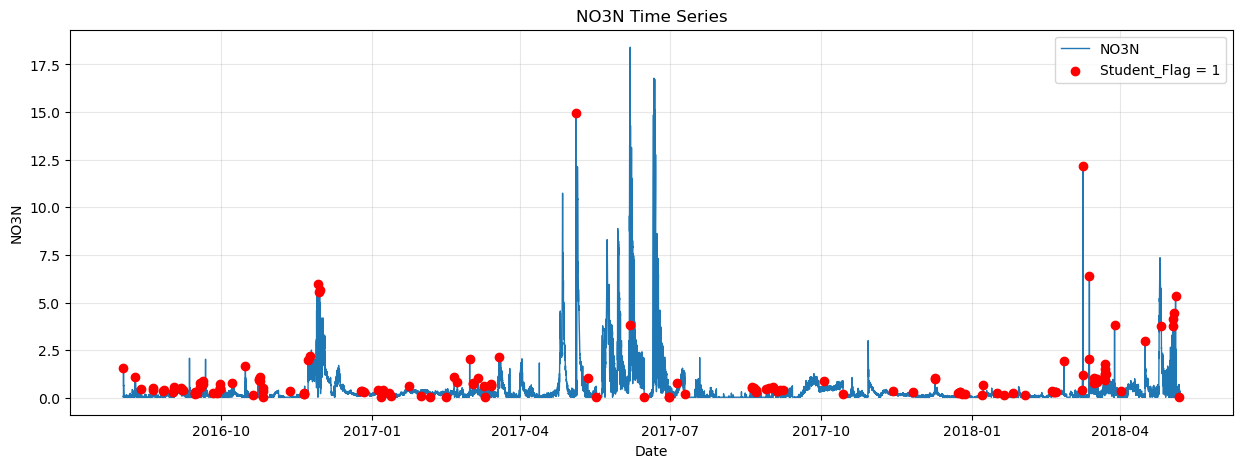

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["Date"],
    df["NO3N"],
    label="NO3N",
    linewidth=1
)

# Overlay known anomalies
anomalies = df["Student_Flag"] == 1

plt.scatter(
    df.loc[anomalies, "Date"],
    df.loc[anomalies, "NO3N"],
    color="red",
    label="Student_Flag = 1",
    zorder=3
)

plt.xlabel("Date")
plt.ylabel("NO3N")
plt.title("NO3N Time Series")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
